# Sesión 5 — Notebook guiado de red neuronal sencilla

## Objetivo
Trabajar con una red neuronal pequeña de clasificación con:

- **2 entradas**
- **1 capa oculta con 2 neuronas**
- **1 neurona de salida**

Después, construir una segunda red similar, pero agregando **1 o 2 neuronas más** en la capa oculta.

## Idea clave
La red aprenderá a clasificar si un caso pertenece a la clase **0** o **1** a partir de dos variables de entrada.

## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Crear una base pequeña de datos

En este ejemplo, las variables son:

- `x1`: horas de estudio
- `x2`: horas de práctica

La salida es:

- `y = 1` si el estudiante **aprueba**
- `y = 0` si el estudiante **no aprueba**

> Nota: esta base es artificial y está hecha para practicar.

In [2]:
data = {
    "x1": [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
    "x2": [1, 2, 1, 2, 2, 3, 2, 4, 3, 4, 4, 5],
    "y":  [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
df

,x1,x2,y
0,1,1,0
1,1,2,0
2,2,1,0
3,2,2,0
4,3,2,0
5,3,3,1
6,4,2,1
7,4,4,1
8,5,3,1
9,5,4,1


### Preguntas iniciales
1. ¿Qué representan `x1` y `x2`?
    Los datos de entrada (horas de estudio y horas de práctica)
2. ¿Qué representa `y`?
    El valor esperado (si aprueban o no)
3. ¿Crees que la clase 1 aparece cuando los valores de entrada son más altos?
    Sí


## 3. Explorar los datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x1      12 non-null     int64
 1   x2      12 non-null     int64
 2   y       12 non-null     int64
dtypes: int64(3)
memory usage: 420.0 bytes


In [4]:
df.describe()

,x1,x2,y
count,12.000000,12.000000,12.000000
mean,3.500000,2.750000,0.583333
std,1.783765,1.288057,0.514929
min,1.000000,1.000000,0.000000
25%,2.000000,2.000000,0.000000
50%,3.500000,2.500000,1.000000
75%,5.000000,4.000000,1.000000
max,6.000000,5.000000,1.000000


## 4. Visualizar la base

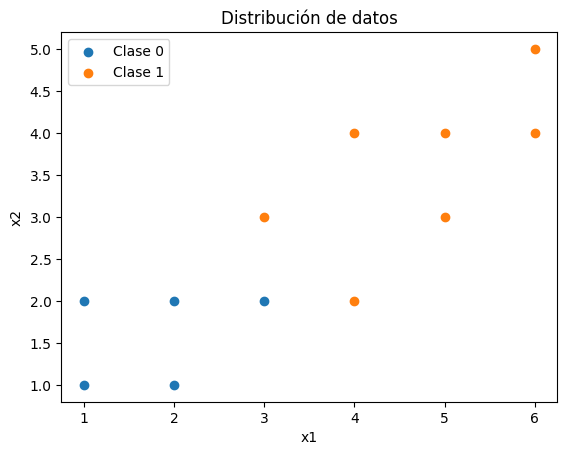

In [5]:
for clase in sorted(df["y"].unique()):
    subset = df[df["y"] == clase]
    plt.scatter(subset["x1"], subset["x2"], label=f"Clase {clase}")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Distribución de datos")
plt.legend()
plt.show()

### Reflexión
4. ¿Se observan zonas donde predominan los 0 y zonas donde predominan los 1?
    Si
5. ¿Crees que una red pequeña podría aprender este patrón?
    Si

## 5. Separar entradas y salida

In [6]:
X = df[["x1", "x2"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Tamaño de entrenamiento:", len(X_train))
print("Tamaño de prueba:", len(X_test))

Tamaño de entrenamiento: 9
Tamaño de prueba: 3


## 6. Crear una red neuronal con la arquitectura trabajada a mano

Usaremos:

- **2 entradas**
- **2 neuronas en la capa oculta**
- **1 salida**

En `scikit-learn`, eso se define con:

```python
hidden_layer_sizes=(2,)
```

In [7]:
model = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation="logistic",
    max_iter=3000,
    random_state=42
)

## 7. Entrenar la red

In [8]:
model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(2,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",3000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 8. Hacer predicciones

In [9]:
predictions = model.predict(X_test)
predictions

array([1, 1, 0])

In [10]:
results = X_test.copy()
results["Real"] = y_test.values
results["Predicción"] = predictions
results

,x1,x2,Real,Predicción
10,6,4,1,1
9,5,4,1,1
0,1,1,0,0


## 9. Evaluar el modelo

In [11]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [12]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, predictions))

Matriz de confusión:
[[1 0]
 [0 2]]


In [13]:
print(classification_report(y_test, predictions, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### Reflexión
6. ¿La red acertó todos los casos de prueba?
    Si
7. ¿En qué casos se equivocó?
    En nada
8. ¿Qué significa accuracy en este contexto?
    Porcentaje de aciertos

## 10. Observar pesos y biases

In [14]:
print("Pesos:")
for i, w in enumerate(model.coefs_):
    print(f"Capa {i} -> {i+1}")
    print(w)
    print()

print("Biases:")
for i, b in enumerate(model.intercepts_):
    print(f"Capa {i+1}")
    print(b)
    print()

Pesos:
Capa 0 -> 1
[[-0.70464141  0.73895179]
 [-0.36509714  0.55957995]]

Capa 1 -> 2
[[-3.35035604]
 [ 3.15034769]]

Biases:
Capa 1
[ 2.38426566 -3.05843794]

Capa 2
[-0.53882706]



### Reflexión
9. ¿Los pesos que encontró la red son iguales a los que usaste a mano?
    No
10. ¿Por qué no necesitamos ajustar estos pesos manualmente en Python?
    Por que la computadora se encarga de reajustar y encontrar los mejores valores

## 11. Probar la red con nuevos datos

In [15]:
new_cases = pd.DataFrame({
    "x1": [2, 4, 6],
    "x2": [3, 2, 5]
})

new_predictions = model.predict(new_cases)
new_probabilities = model.predict_proba(new_cases)

results_new = new_cases.copy()
results_new["Predicción"] = new_predictions
results_new["Probabilidad clase 0"] = new_probabilities[:, 0]
results_new["Probabilidad clase 1"] = new_probabilities[:, 1]
results_new

,x1,x2,Predicción,Probabilidad clase 0,Probabilidad clase 1
0,2,3,0,0.613228,0.386772
1,4,2,1,0.273374,0.726626
2,6,5,1,0.077242,0.922758


### Reflexión
11. ¿Qué caso parece tener más probabilidad de pertenecer a la clase 1?
> el tercer caso (2)
12. ¿Qué diferencia hay entre `predict()` y `predict_proba()`?
> el primero me arroja un valor final (1 o 0), el dos me da más información sobre qué tan cerca estuvo de ser el otro

## 12. Tu turno — construye otra red

Ahora crea una nueva red con arquitectura similar, pero con:

- **3 neuronas** en la capa oculta  
o
- **4 neuronas** en la capa oculta

Completa el siguiente código por tu cuenta.

In [17]:
# Completa este bloque
# Sustituye _____ por 3 o 4

my_model = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation="logistic",
    max_iter=3000,
    random_state=42
)

my_model.fit(X_train, y_train)

my_predictions = my_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, my_predictions))
print(confusion_matrix(y_test, my_predictions))

Accuracy: 1.0
[[1 0]
 [0 2]]


## 13. Comparación final

Responde:

13. ¿Qué arquitectura usaste en tu segunda red?
> 3
14. ¿Mejoró, empeoró o quedó igual respecto a la red con 2 neuronas?
> Quedó igual
15. ¿Agregar neuronas garantiza siempre mejores resultados?
> Puede que incite al overfitting (?)
16. ¿Qué ventajas y desventajas tiene una red más grande?
> Tarda más en entrenar pero puedo está más calibrado

## 14. Cierre

### Idea final
Lo que hiciste a mano en clase fue una versión pequeña de lo que aquí hace la librería automáticamente:

- combinar entradas
- aplicar funciones
- ajustar pesos
- producir una salida

La computadora hace lo mismo, pero más rápido y con muchos más datos.